In [221]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


In [3]:
class Items:
    def __init__(self, n_items, embedding_dim, Wi):
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.input_embedding_Wi = Wi
        self.one_hots = tf.cast(tf.keras.utils.to_categorical(tf.range(self.n_items, dtype=tf.int64).numpy(),
                                                      num_classes=self.n_items), tf.float32)
        self._one_hot_embedded = None
        self.embed_from_one_hot()
    
    def __repr__(self):
        return f"Items(n_items={self.n_items}, embedding_dim={self.embedding_dim})"

    def embed_from_one_hot(self):
        self._one_hot_embedded = tf.tensordot(self.input_embedding_Wi, self.one_hots, axes=1)
    
    def update_embedding(self, new_Wi):
        self.input_embedding_Wi = new_Wi
        self.embed_from_one_hot()

In [4]:
class Transaction(Items):
    def __init__(self, n_items, embedding_dim, n_items_transaction, Wi, Wo):
        super().__init__(n_items, embedding_dim, Wi)
        self.n_items_transaction = n_items_transaction
        self.output_embedding_Wo  = Wo
        self.transaction_items = None
        self.scores = np.zeros((self.n_items_transaction,self.n_items) )
        if self.transaction_items == None:
            self._sample()
    
    def __repr__(self):
        return f"{self.transaction_items.numpy()}"
  
    def _sample(self):
        indices = tf.range(self.n_items, dtype=tf.int64)
        shuffled = tf.random.shuffle(indices)
        sample = shuffled[:self.n_items_transaction]
        self.transaction_items= sample
        return sample
    
    def describe(self):
        print("Transaction:", self.transaction_items.numpy())
        print("\n")
        #print(self.output_embedding_Wo)

    
    def update_embedding(self, new_Wi, new_Wo):
        super().update_embedding(new_Wi)
        self.output_embedding_Wo = new_Wo

In [154]:
class Context:
    def __init__(self, transaction, target_item, wa):
        self.input_embedding_Wi = transaction.input_embedding_Wi
        self.output_embedding_Wo = transaction.output_embedding_Wo
        self.transaction = transaction
        self.target_item = target_item
        self.context_embedding_wa = wa
        self.context_items = tf.boolean_mask(self.transaction.transaction_items, self.transaction.transaction_items != target_item)
        self.context_embedding = None
        self.alpha_weights = None
        self.scores = None
        self.relevance_scores = None
    
    def __repr__(self):
        return f"context items ={self.context_items.numpy()}"
    
    
    def _compute_alpha_weights(self):
        e_h = tf.linalg.matvec(tf.transpose(tf.gather(self.input_embedding_Wi, self.context_items, axis=1)),
                                self.context_embedding_wa)    # [e(h_j) for j in card(context)] 
        exponents = tf.exp(e_h)
        self.alpha_weights = exponents / tf.reduce_sum(exponents)
    
    def _context_embed(self): 
        self._compute_alpha_weights()
        self.context_embedding = tf.tensordot(tf.gather(self.input_embedding_Wi, self.context_items, axis=1),self.alpha_weights, axes=1)

    def relevance(self):
        self.scores[self.target_item] = tf.linalg.matvec(self.output_embedding_Wo, self.context_embedding)
        # Softmax to get probabilities (TensorFlow)
        probabilities = tf.nn.softmax(self.scores[self.target_item])
        self.relevance_scores = probabilities.numpy() 
        return np.argmax(probabilities), np.max(probabilities)
    
    def relevance(self):
        self.scores = tf.linalg.matvec(self.output_embedding_Wo, self.context_embedding)  # shape: (n_items,)
        probabilities = tf.nn.softmax(self.scores)
        self.relevance_scores = probabilities.numpy()
        target_prob = probabilities[self.target_item].numpy()

        # Getting index of most relevant item not in the context
        context_indices = set(self.context_items.numpy().tolist())
        all_indices = set(range(len(self.scores)))
        non_context_indices = np.array(list(all_indices - context_indices))

        non_context_scores = self.scores.numpy()[non_context_indices]
        idx_in_non_context = np.argmax(non_context_scores)
        most_relevant = non_context_indices[idx_in_non_context]
        max_score = non_context_scores[idx_in_non_context]

        return most_relevant, max_score, target_prob

    def describe(self):
        self._context_embed()
        print("Target item is", self.target_item," in the context:",self.context_items.numpy() )
        #print("Context Embedding:", self.context_embedding.numpy())
        most_relevant, score, target_prob = self.relevance()
        print("Most relevant item is", most_relevant, '\n')

    def update_embedding(self, new_Wi, new_Wo, new_wa):
        self.input_embedding_Wi = new_Wi
        self.output_embedding_Wo = new_Wo
        self.context_embedding_wa = new_wa


In [222]:
# Let's suppose card(t) is the same for all transactions for now

class Pair:
    def __init__(self, Wi, wa, Wo, n_items, dim, n_items_transaction, sample = True, context = None, target_item = None):
        self.context = None
        self.n_items = n_items
        self._n_items_transaction = n_items_transaction
        self.dim = dim
        self.target_item = None
        self.transaction = None
        if context != None:
            self.context = context
        if target_item != None:
            self.target_item = target_item
        self.Theta = [Wi, wa, Wo]
        if sample != None and sample:
            self._random_sampling()
    
    def __repr__(self):
        return f"The new pair is ({self.target_item}, of {self.context}, from the transaction {self.transaction})"
    
    def _random_sampling(self):
        Wi, wa, Wo = self.Theta
        transaction = Transaction(self.n_items,self.dim,self._n_items_transaction,Wi,Wo)
        self.transaction = transaction
        self.target_item = np.random.choice(transaction.transaction_items)
        self.context = Context(transaction, self.target_item, wa)

class Dataset_of_pairs:
    def __init__(self, n_pairs, Wi, Wo, wa, n_items, dim, n_items_transaction, sample = True):
        self.dim = dim
        self.n_items_transaction = n_items_transaction
        self.n_pairs = n_pairs
        self.n_items = n_items
        self.Theta = [Wi, wa, Wo]
        self.pairs = []
        self.t = t
        if self.pairs == [] and sample != None and sample:
            self._create_random_dataset()


    def _create_random_dataset(self):
        Wi, wa, Wo = self.Theta
        for _ in range(self.n_pairs):
            self.pairs.append(Pair(Wi,wa,Wo, self.n_items, self.dim, self.n_items_transaction))
        #print(f"A new dataset of {self.n_pairs} pairs has been created \n")
    
    def __repr__(self):
        return "\n".join(
            f"Pair {i}: (target_item={pair.target_item}, context={pair.context.context_items.numpy()}, transaction={pair.transaction})"
            for i, pair in enumerate(self.pairs)
        )

In [223]:
"""
# First learning approach, not adapted to huge training databases
# Fatal !!!

import matplotlib.pyplot as plt

learning_rate = 0.01
epochs = 400
n_pairs = 20

optimizer = tf.keras.optimizers.Adam(learning_rate)
loss_history = []

def compute_loss(pairs):
    total_loss = 0.0
    for pair in pairs:
        ctx = pair.context
        ctx._context_embed()
        scores = tf.linalg.matvec(ctx.output_embedding_Wo, ctx.context_embedding) 
        S_ic = scores[ctx.target_item]
        Z_c = tf.reduce_sum(tf.exp(scores))
        loss = S_ic - tf.math.log(Z_c)
        total_loss += loss
    return -total_loss / len(pairs)  

for epoch in range(epochs):
    dataset = Dataset_of_pairs(n_pairs) ### Necessary? to reduce variance
    with tf.GradientTape() as tape:
        loss = compute_loss(dataset.pairs)
    variables = [var for var in [Wi, wa, Wo] if isinstance(var, tf.Variable)]
    grads = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(grads, variables))
    loss_history.append(loss.numpy())
    if (epoch+1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}")

print("Optimization finished.")

# Plot the loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history)  # No marker='o'
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()
"""

'\n# First learning approach, not adapted to huge training databases\n# Fatal !!!\n\nimport matplotlib.pyplot as plt\n\nlearning_rate = 0.01\nepochs = 400\nn_pairs = 20\n\noptimizer = tf.keras.optimizers.Adam(learning_rate)\nloss_history = []\n\ndef compute_loss(pairs):\n    total_loss = 0.0\n    for pair in pairs:\n        ctx = pair.context\n        ctx._context_embed()\n        scores = tf.linalg.matvec(ctx.output_embedding_Wo, ctx.context_embedding) \n        S_ic = scores[ctx.target_item]\n        Z_c = tf.reduce_sum(tf.exp(scores))\n        loss = S_ic - tf.math.log(Z_c)\n        total_loss += loss\n    return -total_loss / len(pairs)  \n\nfor epoch in range(epochs):\n    dataset = Dataset_of_pairs(n_pairs) ### Necessary? to reduce variance\n    with tf.GradientTape() as tape:\n        loss = compute_loss(dataset.pairs)\n    variables = [var for var in [Wi, wa, Wo] if isinstance(var, tf.Variable)]\n    grads = tape.gradient(loss, variables)\n    optimizer.apply_gradients(zip(grad

In [230]:
def train_nce(
    Wi, wa, Wo,
    dataset, n_items,
    epochs=1500, 
    K_noise=9, 
    learning_rate=0.01, 
    verbose=True
):
    optimizer = tf.keras.optimizers.Adam(learning_rate)
    loss_history = []

    def compute_nce_loss(pairs, Wi, Wo, wa, K_noise):
        total_loss = 0.0
        n_items = pairs[0].context.transaction.n_items
        Q = 1.0 / K_noise  # Uniform noise distribution

        batch_size = K_noise + 1
        idx = np.random.choice(len(pairs), batch_size, replace=False)
        batch = [pairs[i] for i in idx]
        for pair in batch:
            pair.context.update_embedding(Wi, Wo, wa)
            pair.context._context_embed()

        pos_pair = batch[0]
        ctx = pos_pair.context
        scores = tf.linalg.matvec(ctx.output_embedding_Wo, ctx.context_embedding)
        S_ic = scores[ctx.target_item]

        transaction_items = set(ctx.transaction.transaction_items.numpy().tolist())
        all_items = set(range(n_items))
        candidate_neg_items = list(all_items - transaction_items)
        random.shuffle(candidate_neg_items)
        neg_items = candidate_neg_items[:K_noise]  # Take first K_noise

        S_neg = tf.gather(scores, neg_items)

        log_Q = np.log(Q)
        pos_term = tf.math.log_sigmoid(S_ic - log_Q)
        neg_term = tf.reduce_sum(tf.math.log_sigmoid(-S_neg + log_Q))
        loss = -(pos_term + neg_term)
        total_loss += loss

        return total_loss
    

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            loss = compute_nce_loss(dataset.pairs, Wi, Wo, wa,  K_noise=K_noise)
        variables = [var for var in [Wi, wa, Wo] if isinstance(var, tf.Variable)]
        grads = tape.gradient(loss, variables)
        optimizer.apply_gradients(zip(grads, variables))
        loss_history.append(loss.numpy())
        if verbose and ((epoch+1) % 200 == 0 or epoch == 0):
            print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}")

    print("Optimization finished.")

    # Plot the loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('NCE Loss')
    plt.title('NCE Training Loss Curve')
    plt.grid(True)
    plt.show()
    return loss_history

Transaction: [4 6 0]


Target item is 4  in the context: [6 0]
Most relevant item is 11 

Target item is 6  in the context: [4 0]
Most relevant item is 8 

Target item is 0  in the context: [4 6]
Most relevant item is 11 

Epoch 1, Loss: 27.6257
Epoch 200, Loss: 3.7755
Epoch 400, Loss: 1.8171
Epoch 600, Loss: 1.7544
Epoch 800, Loss: 0.9838
Epoch 1000, Loss: 0.1475
Epoch 1200, Loss: 0.1091
Epoch 1400, Loss: 0.5185
Optimization finished.


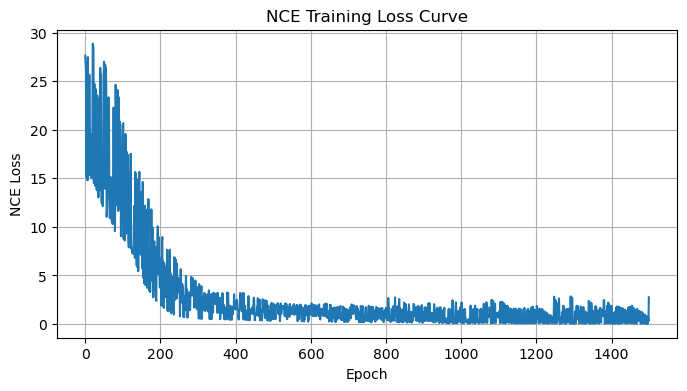

Target item is 4  in the context: [6 0]
Most relevant item is 9 

Transaction [4 6 0] 

Target item is 6  in the context: [4 0]
Most relevant item is 1 

Transaction [4 6 0] 

Target item is 0  in the context: [4 6]
Most relevant item is 8 

Transaction [4 6 0] 



In [233]:
if __name__ == "__main__":
    K = 7
    I = 12
    t = 3
    n_pairs = 10
    Wi = tf.Variable(tf.random.normal([K, I]), trainable=True, name="Wi")
    wa = tf.Variable(tf.random.normal([K]), trainable=True, name="w_alpha")
    Wo = tf.Variable(tf.random.normal([I, K]), trainable=True, name="Wo")
    

    # New transaction
    transaction = Transaction(I, K, t, Wi, Wo)
    transaction.describe()

    # All contexts for this transaction / might be reasonable to only create and display a few
    contexts = []
    for target_item in transaction.transaction_items.numpy():
        ctx = Context(transaction, int(target_item), wa)
        contexts.append(ctx)

    # Describe all created contexts

    for ctx in contexts:
        ctx.describe()
        

    """
    # To test the creation of the dataset
    newDataset = Dataset_of_pairs(10)
    print(newDataset)
    """
    
    # Generate training dataset once
    dataset = Dataset_of_pairs(n_pairs, Wi, Wo, wa, I, K, t)

    # Call training model
    train_nce(Wi, wa, Wo, dataset, I)

    # Verify that the next item prediction works well on the illustrating transaction

    for ctx in contexts:
        ctx.update_embedding(Wi, Wo, wa)
        ctx.describe()
        print("Transaction", ctx.transaction, "\n")
    

In [ ]:
def compute_nce_loss(pairs, K_noise=5, n_items=10):
        total_loss = 0.0
        Q = 1.0 / n_items  # Uniform noise distribution

        ## Ça marche mais c'est hyper bet de faire loop sur toutes les paires, next task: prendre une paire et la considérer pos et K paires et les transformer en neg
        for pair in pairs:
            ctx = pair.context
            ctx._context_embed()
            scores = tf.linalg.matvec(ctx.output_embedding_Wo, ctx.context_embedding) 
            S_ic = scores[ctx.target_item]
            
            # Positive term
            numerator = tf.exp(S_ic)
            denominator = numerator + K_noise * Q
            log_P_pos = tf.math.log(numerator / denominator + 1e-10) 
            
            # Negative samples
            neg_items = []
            while len(neg_items) < K_noise:
                neg = np.random.randint(0, n_items)
                if neg not in ctx.transaction.transaction_items:
                    neg_items.append(neg)
            neg_items = np.array(neg_items)
            S_neg = tf.gather(scores, neg_items)
            numerator_neg = K_noise * Q
            denominator_neg = tf.exp(S_neg) + K_noise * Q
            log_P_neg = tf.math.log(numerator_neg / denominator_neg + 1e-10)  
            neg_term = tf.reduce_sum(log_P_neg)
        
            J = log_P_pos + neg_term
            total_loss += J

        return -total_loss / len(pairs)